<a href="https://colab.research.google.com/github/ShivaniYadav354/Customer-Chrum-Prediction-Model/blob/main/project_2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import shap
import warnings
warnings.filterwarnings("ignore")

# Step 2: Load the Dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))
df.head()


Saving customer_churn_dataset.csv to customer_churn_dataset.csv


,Customer_ID,Age,Gender,Monthly_Spending,Subscription_Length,Support_Interactions,Churn
0,1,56,0,275,2,3,0
1,2,69,0,381,8,1,0
2,3,46,1,219,5,2,0
3,4,32,1,58,2,2,0
4,5,60,1,89,4,4,0


**Data Understanding**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Customer_ID           1000 non-null   int64
 1   Age                   1000 non-null   int64
 2   Gender                1000 non-null   int64
 3   Monthly_Spending      1000 non-null   int64
 4   Subscription_Length   1000 non-null   int64
 5   Support_Interactions  1000 non-null   int64
 6   Churn                 1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB
None
       Customer_ID          Age       Gender  Monthly_Spending  \
count  1000.000000  1000.000000  1000.000000       1000.000000   
mean    500.500000    44.385000     0.476000        275.791000   
std     288.819436    15.321669     0.499674        131.061193   
min       1.000000    18.000000     0.000000         50.000000   
25%     250.750000    31.750000     0.000000        166.000000   
50%     500.50

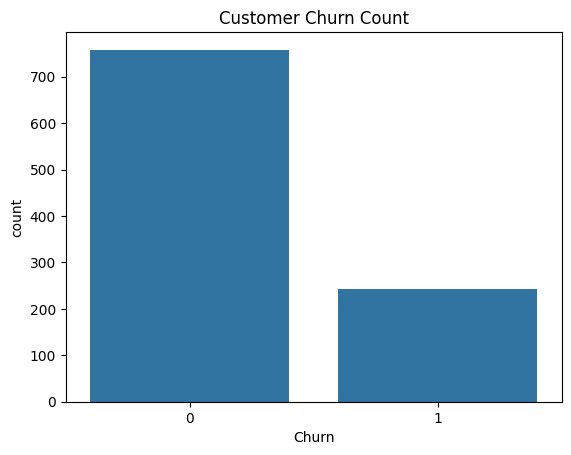

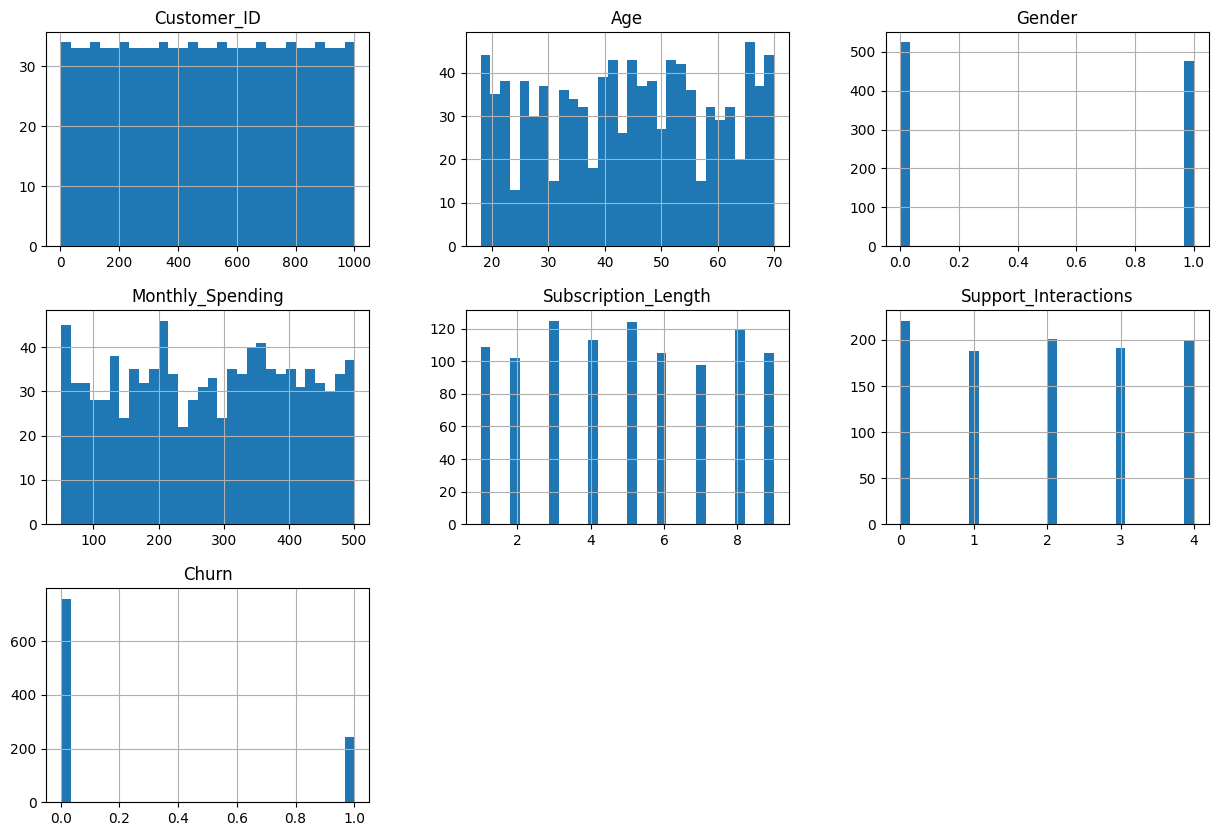

In [ ]:
print(df.info())
print(df.describe())

# Visualize Churn Distribution
sns.countplot(data=df, x='Churn')
plt.title("Customer Churn Count")
plt.show()

# Visualize numerical features
df.hist(bins=30, figsize=(15, 10))
plt.show()


**Data Preparation**

In [ ]:
# Drop customerID if it exists
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Check and convert 'TotalCharges' only if it exists
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing values
df = df.dropna()

# Encode all object type columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Separate features and target
if 'Churn' in df.columns:
    X = df.drop('Churn', axis=1)
    y = df['Churn']
else:
    print("⚠️ 'Churn' column not found! Please check your dataset.")

# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


**Modeling**

In [ ]:
# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)


 **Evaluation Methodology**

--- Logistic Regression ---
[[154   0]
 [ 46   0]]
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       154
           1       0.00      0.00      0.00        46

    accuracy                           0.77       200
   macro avg       0.39      0.50      0.44       200
weighted avg       0.59      0.77      0.67       200

--- Random Forest ---
[[147   7]
 [ 46   0]]
              precision    recall  f1-score   support

           0       0.76      0.95      0.85       154
           1       0.00      0.00      0.00        46

    accuracy                           0.73       200
   macro avg       0.38      0.48      0.42       200
weighted avg       0.59      0.73      0.65       200

--- Gradient Boosting ---
[[148   6]
 [ 44   2]]
              precision    recall  f1-score   support

           0       0.77      0.96      0.86       154
           1       0.25      0.04      0.07        46

    accuracy                         

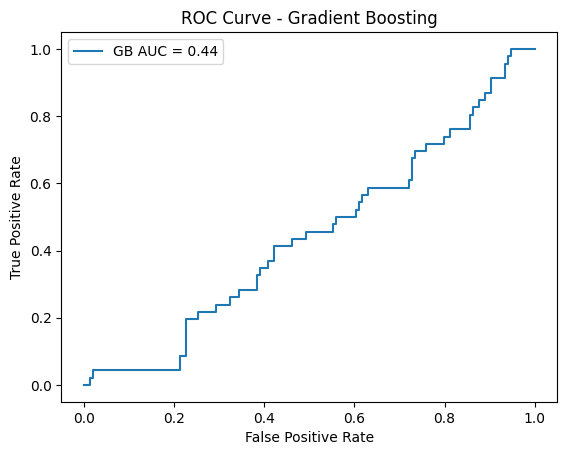

In [ ]:
models = {
    "Logistic Regression": log_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

for name, pred in models.items():
    print(f"--- {name} ---")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))

# ROC-AUC for Gradient Boosting
gb_probs = gb_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, gb_probs)
fpr, tpr, _ = roc_curve(y_test, gb_probs)

plt.plot(fpr, tpr, label=f'GB AUC = {roc_auc:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend()
plt.show()


**Managerial Implications**

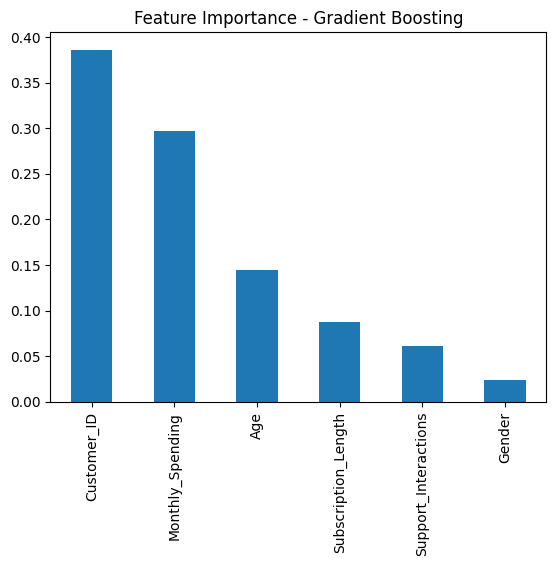

In [ ]:
# Feature Importance
feature_imp = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_imp.plot(kind='bar', title='Feature Importance - Gradient Boosting')
plt.show()


**Novelty & Optimization**

Best RF Parameters: {'max_depth': 10, 'n_estimators': 100}


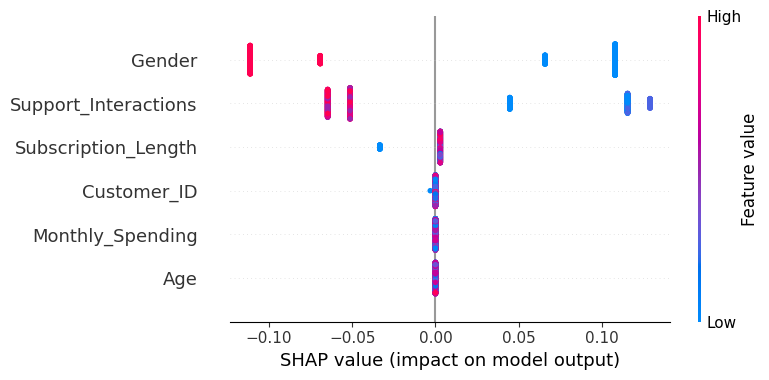

In [ ]:
# Hyperparameter tuning on Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)
print("Best RF Parameters:", grid.best_params_)

# SHAP Explanation
explainer = shap.Explainer(gb_model, X)
shap_values = explainer(X)
shap.summary_plot(shap_values, X)
